<a href="https://colab.research.google.com/github/sdg331/BDA404/blob/main/projects_01/%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89_%EB%B0%9C%ED%91%9C%EC%9E%90%EB%A3%8C_%EC%88%98%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 타이타닉 생존자 데이터 분석

### 1,309명의 탑승객 데이터로 살펴보는 *"생존을 가른 조건"*

---

- **데이터셋** &nbsp;·&nbsp; `titanic1309.csv` — 타이타닉호 전체 탑승객 1,309명
- **분석 흐름** &nbsp;·&nbsp; 데이터 확인 → 정제 → 항목별 분석 → 종합 인사이트
- **작성자** &nbsp;·&nbsp; 김나우

> Colab에서 실행할 경우, 먼저 `titanic1309.csv` 파일을 업로드한 뒤 위에서부터 셀을 순서대로 실행하세요 (`Shift + Enter`).

## 1. 분석 배경과 목적

1912년 4월, 당시 세계 최대 규모의 여객선 **타이타닉호**는 첫 항해 도중 빙산과 충돌해 침몰했고, 탑승객의 다수가 목숨을 잃었습니다.

이 분석의 목적은 단순히 *"몇 명이 살아남았는가"* 가 아니라 **"누가, 왜 살아남았는가"** 를 데이터로 규명하는 것입니다. 승객의 성별·나이·객실 등급·동반 가족 등 여러 조건이 생존 여부와 어떻게 연결되는지 단계적으로 확인합니다.

**분석 흐름**

1. **라이브러리 로드와 데이터 확인** — 데이터의 구조·결측치·이상치 파악
2. **데이터 정제** — 분석을 왜곡하지 않도록 결측치 처리 및 변수 구간화
3. **분석** — 변수별 *생존자 수*와 *생존률*을 시각화해 비교
4. **분석 결과 · 인사이트** — 변수들을 엮어 핵심 결론과 시사점 도출

# 2. 라이브러리 로드와 데이터 확인

## 2.1. 분석 환경 설정

분석에 필요한 라이브러리를 불러오고, 한글이 깨지지 않도록 폰트를 설정합니다. 또한 모든 그래프가 **일관된 색과 형식**을 따르도록 공통 색상 팔레트와 보조 함수를 미리 정의합니다.

- 🟢 **청록색**(`#2a9d8f`) = 생존 &nbsp;·&nbsp; 🟠 **주황색**(`#e76f51`) = 사망

In [3]:
%pip install koreanize-matplotlib

In [4]:
# ============================================================
#  환경 설정 — 라이브러리 · 한글 폰트 · 공통 그래프 디자인
# ============================================================
import os, subprocess, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import koreanize_matplotlib

# --- 경고 메시지 무시

# warnings.filterwarnings("ignore")

# # --- 한글 폰트 설정 (Colab / 로컬 환경 모두 대응) ---
# def setup_korean_font():
#     # Use standard sans-serif font for headless rendering to avoid missing font issues
#     plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
#     return "DejaVu Sans"

# sns.set_style("whitegrid")
# _font = setup_korean_font()
# plt.rcParams["axes.unicode_minus"] = False
# plt.rcParams.update({
#     "figure.dpi": 120, "font.size": 11, "axes.titlesize": 13,
#     "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
#     "legend.fontsize": 10, "figure.titlesize": 15,
# })

# --- 공통 색상 팔레트 (생존=청록 / 사망=주황 / 수치 막대=네이비) ---
C_SURV, C_DIED, C_RATE = "#2a9d8f", "#e76f51", "#264653"
C_CLASS = ["#2a9d8f", "#e9c46a", "#e76f51"]   # 1·2·3등석

# --- (1) 막대 위에 수치 라벨을 달아 가독성을 높이는 헬퍼 ---
def annotate_bars(ax, fmt="{:.1f}%", fontsize=10, dy=2):
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=fontsize,
                        xytext=(0, dy), textcoords="offset points")

# --- (2) 변수별 생존 분석 그래프 헬퍼 ---
#     (좌) 생존자 수·사망자 수 누적 막대  /  (우) 생존률(%) 막대
def plot_survival_by(data, col, title, order=None, rate_palette=None,
                     label_map=None, rotate=0, min_label=8):
    if order is None:
        order = sorted(data[col].dropna().unique())
    surv = data.loc[data["Survived"] == 1, col].value_counts()
    died = data.loc[data["Survived"] == 0, col].value_counts()
    s = [int(surv.get(c, 0)) for c in order]
    d = [int(died.get(c, 0)) for c in order]
    rate = (data.groupby(col, observed=True)["Survived"].mean()
                .reindex(order) * 100)
    labels = [str(label_map.get(c, c)) if label_map else str(c) for c in order]
    x = list(range(len(order)))
    mean_rate = data["Survived"].mean() * 100

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
    fig.suptitle(title, fontweight="bold", fontsize=14)

    # (좌) 생존자 수 · 사망자 수 — 누적 막대
    ax[0].bar(x, s, width=0.6, color=C_SURV, label="생존")
    ax[0].bar(x, d, width=0.6, bottom=s, color=C_DIED, label="사망")
    for i in x:
        if s[i] >= min_label:
            ax[0].text(i, s[i] / 2, f"{s[i]}명", ha="center", va="center",
                       color="white", fontweight="bold", fontsize=9)
        if d[i] >= min_label:
            ax[0].text(i, s[i] + d[i] / 2, f"{d[i]}명", ha="center", va="center",
                       color="white", fontweight="bold", fontsize=9)
    ax[0].set_title("① 생존자 수 · 사망자 수", fontsize=12)
    ax[0].set_ylabel("인원 수 (명)")
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(labels, rotation=rotate,
                          ha="right" if rotate else "center")
    ax[0].legend()

    # (우) 생존률(%)
    colors = rate_palette if rate_palette is not None else [C_RATE] * len(order)
    ax[1].bar(x, rate.values, width=0.6, color=colors)
    ax[1].axhline(mean_rate, ls="--", color="gray", lw=1.2)
    ax[1].text(len(order) - 0.45, mean_rate + 2.5, f"전체 평균 {mean_rate:.1f}%",
               ha="right", color="gray", fontsize=9)
    ax[1].set_title("② 생존률 (%)", fontsize=12)
    ax[1].set_ylabel("생존률 (%)")
    ax[1].set_ylim(0, 100)
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(labels, rotation=rotate,
                          ha="right" if rotate else "center")
    annotate_bars(ax[1])

    plt.tight_layout()
    plt.show()

    summ = pd.DataFrame({"생존": s, "사망": d}, index=labels)
    summ["인원수"] = summ["생존"] + summ["사망"]
    summ["생존률(%)"] = rate.values.round(1)
    print(summ[["인원수", "생존", "사망", "생존률(%)"]].to_string())

# print("환경 설정 완료 — 한글 폰트:", _font)

## 2.2. 데이터셋(`titanic1309.csv`) 로드 및 구조 파악

타이타닉 데이터셋은 **1,309개의 행과 12개 열**로 이루어져 있습니다. 각 열의 의미는 다음과 같습니다.

| 변수명 | 의미 | 타입 | 분석 시 참고 사항 |
| :--- | :--- | :--- | :--- |
| **PassengerId** | 승객 고유 번호 | 정수 | 1부터 시작하는 단순 식별자 |
| **Survived** | 생존 여부 | 정수 | **0 = 사망, 1 = 생존** |
| **Pclass** | 티켓 등급(객실 등급) | 정수 | **1 = 1등석, 2 = 2등석, 3 = 3등석** |
| **Name** | 승객 이름 | 문자열 | 호칭(Mr·Mrs·Miss 등) 추출 가능 |
| **Sex** | 성별 | 문자열 | male(남성) / female(여성) |
| **Age** | 나이 | 실수 | 결측치 263개 존재 |
| **SibSp** | 동반한 형제·배우자 수 | 정수 | 가족 동반 여부 파악 |
| **Parch** | 동반한 부모·자녀 수 | 정수 | 가족 동반 여부 파악 |
| **Ticket** | 티켓 번호 | 문자열 | 일반적으로 분석 제외 |
| **Fare** | 여객 운임(티켓 가격) | 실수 | 결측치 1개, Pclass와 강한 상관 |
| **Cabin** | 객실 번호 | 문자열 | 결측치 매우 많음(1,014개) |
| **Embarked** | 탑승 항구 | 문자열 | C=셰르부르, Q=퀸스타운, S=사우샘프턴 |

> 변수는 크게 **숫자형**(Age·Fare·SibSp·Parch), **범주형**(Pclass·Sex·Embarked), **고유 식별 변수**(PassengerId·Name·Ticket·Cabin)로 나뉩니다.

In [5]:
# 데이터 로드 — titanic1309.csv (타이타닉호 전체 탑승객 1,309명)
tt = pd.read_csv("titanic1309.csv")

print(f"전체 데이터 크기 : {tt.shape[0]:,}행 × {tt.shape[1]}열")
print(f"전체 생존률      : {tt['Survived'].mean()*100:.1f}%  "
      f"(생존 {tt['Survived'].sum()}명 / 사망 {(tt['Survived']==0).sum()}명)")

# PassengerId 가 고유 식별자로서 결측·중복이 없는지 확인
print(f"\nPassengerId 고유성 : {tt['PassengerId'].is_unique}  /  "
      f"결측치 : {tt['PassengerId'].isnull().sum()}개")

print("\n[상위 5개 행 미리보기]")
print(tt[["Pclass", "Survived", "Sex", "Age",
          "SibSp", "Parch", "Fare", "Embarked"]].head())

print("\n[주요 범주형 변수의 고유값]")
for c in ["Pclass", "Survived", "Sex", "Embarked"]:
    print(f"  {c:9s}: {sorted(tt[c].dropna().unique())}")

전체 데이터 크기 : 1,309행 × 12열
전체 생존률      : 37.7%  (생존 494명 / 사망 815명)

PassengerId 고유성 : True  /  결측치 : 0개

[상위 5개 행 미리보기]
   Pclass  Survived     Sex   Age  SibSp  Parch     Fare Embarked
0       3         0    male  22.0      1      0   7.2500        S
1       1         1  female  38.0      1      0  71.2833        C
2       3         1  female  26.0      0      0   7.9250        S
3       1         1  female  35.0      1      0  53.1000        S
4       3         0    male  35.0      0      0   8.0500        S

[주요 범주형 변수의 고유값]
  Pclass   : [np.int64(1), np.int64(2), np.int64(3)]
  Survived : [np.int64(0), np.int64(1)]
  Sex      : ['female', 'male']
  Embarked : ['C', 'Q', 'S']


## 2.3. 변수별 결측치 확인

`info()`로 데이터 타입과 결측치 현황을 확인합니다.

In [6]:
print("=== 데이터 요약 정보 (info) ===")
tt.info()

print("\n[변수별 결측치 개수]")
miss = tt.isnull().sum()
print(miss[miss > 0].to_string())

=== 데이터 요약 정보 (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB

[변수별 결측치 개수]
Age          263
Fare           1
Cabin       1014
Embarked       2


**결측치 현황** — 나이(Age) 263개, 객실 번호(Cabin) 1,014개, 탑승 항구(Embarked) 2개, 요금(Fare) 1개의 결측치가 존재합니다. 결측치가 있는 상태로 분석하면 오류가 나거나 결과가 왜곡될 수 있으므로, 다음 단계(**3장**)에서 변수별 특성에 맞게 처리합니다.

## 2.4. 이상치 확인 — 요금(Fare) 변수

요금(Fare)의 분포를 박스플롯으로 확인하고, 객실 등급별 탑승 인원을 함께 살펴봅니다.

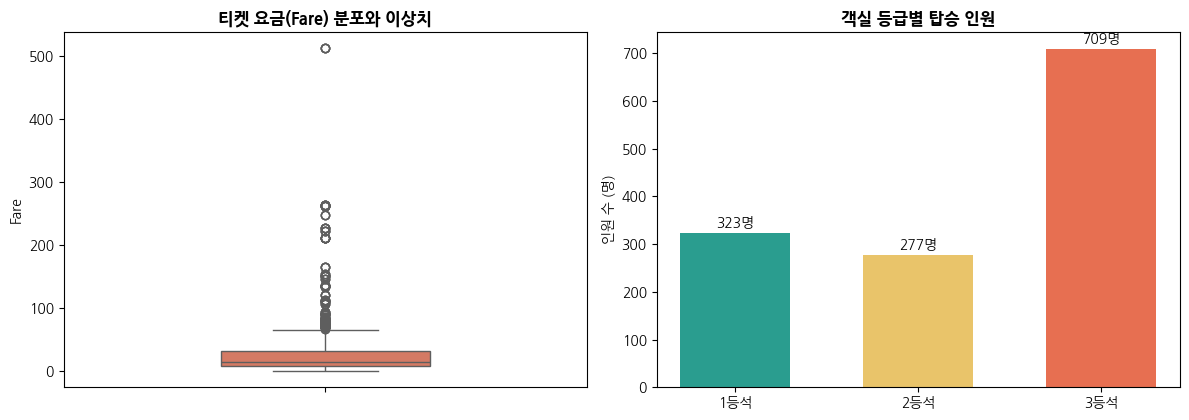

요금(Fare)이 0원인 승객 수 : 17명

[객실 등급별 평균 요금]
Pclass
1    87.51
2    21.18
3    13.30


In [7]:
# (좌) Fare 분포의 박스플롯 — 이상치 확인  /  (우) 객실 등급별 탑승 인원
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))

sns.boxplot(y="Fare", data=tt, ax=ax[0], color=C_DIED, width=0.4)
ax[0].set_title("티켓 요금(Fare) 분포와 이상치", fontweight="bold")
ax[0].set_ylabel("Fare")

cnt = tt["Pclass"].value_counts().sort_index()
ax[1].bar(["1등석", "2등석", "3등석"], cnt.values, color=C_CLASS, width=0.6)
for i, v in enumerate(cnt.values):
    ax[1].annotate(f"{v}명", (i, v), ha="center", va="bottom",
                   xytext=(0, 2), textcoords="offset points")
ax[1].set_title("객실 등급별 탑승 인원", fontweight="bold")
ax[1].set_ylabel("인원 수 (명)")

plt.tight_layout()
plt.show()

print(f"요금(Fare)이 0원인 승객 수 : {(tt['Fare'] == 0).sum()}명")
print("\n[객실 등급별 평균 요금]")
print(tt.groupby("Pclass")["Fare"].mean().round(2).to_string())

# 3. 데이터 정제

## 3.1. 변수 특성별 결측치 처리 기준

결측치를 그대로 두면 분석이 왜곡되거나 오류가 납니다. 변수의 **성격에 맞는 방식**으로 빈칸을 채웁니다.

| 변수 | 결측 | 처리 방법 | 근거 |
| :--- | :--- | :--- | :--- |
| `Embarked` | 2개 | **최빈값(S)** 으로 대체 | 범주형이라 평균을 낼 수 없고, 결측이 2개뿐이라 영향이 작음 |
| `Fare` | 1개 (+0원 17개) | **객실 등급별 중앙값** 으로 대체 | 극단적 고가 티켓 탓에 평균은 왜곡 → 대푯값으로 중앙값 사용. 등급별로 가격대가 다르므로 등급별로 세분화 |
| `Age` | 263개 | **성별·객실 등급별 평균** 으로 대체 | 성별·자산(등급)에 따라 연령 분포가 다름 (1등석엔 부유한 중장년, 3등석엔 젊은 노동층이 많음) |
| `Cabin` | 1,014개 (≈77%) | **별도 범주로 보존** | 77%가 결측 → 대체 불가. '기록 없음' 자체를 하나의 정보로 다룸 |

> 💡 평균이 아닌 **중앙값**을 쓰는 이유 — 요금처럼 일부 극단값이 섞인 변수는 평균이 위로 끌려가 대표성을 잃기 때문입니다.

In [8]:
# 1) Fare 의 0원 값을 결측치(NaN)로 치환 — 실제로는 '요금 정보 없음'으로 판단
tt["Fare"] = tt["Fare"].replace(0, np.nan)

print("[정제 전 결측치]")
print(tt[["Age", "Fare", "Embarked", "Cabin"]].isnull().sum().to_string())

# 2) Embarked : 최빈값(S)으로 대체
tt["Embarked"] = tt["Embarked"].fillna(tt["Embarked"].mode()[0])
# 3) Fare : 객실 등급(Pclass)별 중앙값으로 대체
tt["Fare"] = tt.groupby("Pclass")["Fare"].transform(lambda s: s.fillna(s.median()))
# 4) Age : 성별(Sex)·객실 등급(Pclass)별 평균으로 대체
tt["Age"] = tt.groupby(["Sex", "Pclass"])["Age"].transform(lambda s: s.fillna(s.mean()))

print("\n[정제 후 결측치]  (Cabin 은 별도 범주로 보존)")
print(tt[["Age", "Fare", "Embarked"]].isnull().sum().to_string())
print("\n정제 완료 — 분석 준비됨")

[정제 전 결측치]
Age          263
Fare          18
Embarked       2
Cabin       1014

[정제 후 결측치]  (Cabin 은 별도 범주로 보존)
Age         0
Fare        0
Embarked    0

정제 완료 — 분석 준비됨


## 3.2. 변수 구간화

나이(Age)와 요금(Fare)은 값의 종류가 매우 많아 그대로는 비교가 어렵습니다. 이를 **연령대**(Age_Bin)와 **요금 구간**(Fare_Bin)이라는 범주형 변수로 가공해 분석의 효율성과 가독성을 높입니다. 객실 번호(Cabin)는 **기록 유무**(Cabin_Bin)로 단순화합니다.

| 파생 변수 | 원본 | 구간 |
| :--- | :--- | :--- |
| `Age_Bin` | Age | Child(0-12) · Teenager(13-19) · Young Adult(20-35) · Adult(36-60) · Elderly(60+) |
| `Fare_Bin` | Fare | Low · Medium-Low · Medium-High · High (요금 4분위) |
| `Cabin_Bin` | Cabin | Yes(기록 있음) · No(기록 없음) |

In [9]:
# 1) 나이 → 5개 연령대 (Age_Bin)
tt["Age_Bin"] = pd.cut(
    tt["Age"], bins=[0, 12, 19, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Elderly"])

# 2) 요금 → 4분위 구간 (Fare_Bin)
tt["Fare_Bin"] = pd.qcut(
    tt["Fare"], q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"])

# 3) 객실 번호 기록 유무 (Cabin_Bin) — 비어 있으면 'No', 값이 있으면 'Yes'
tt["Cabin_Bin"] = tt["Cabin"].isnull().map({True: "No", False: "Yes"})

print("[연령대(Age_Bin)별 인원]")
print(tt["Age_Bin"].value_counts().sort_index().to_string())
print("\n[요금 구간(Fare_Bin)별 인원]")
print(tt["Fare_Bin"].value_counts().sort_index().to_string())
print("\n[객실 기록 유무(Cabin_Bin)별 인원]")
print(tt["Cabin_Bin"].value_counts().to_string())

[연령대(Age_Bin)별 인원]
Age_Bin
Child           94
Teenager       131
Young Adult    723
Adult          328
Elderly         33

[요금 구간(Fare_Bin)별 인원]
Fare_Bin
Low            343
Medium-Low     317
Medium-High    326
High           323

[객실 기록 유무(Cabin_Bin)별 인원]
Cabin_Bin
No     1014
Yes     295


# 4. 분석

## 4.1. 전체 분석 — 핵심 변수 한눈에 보기

본격적인 항목별 분석에 앞서, 핵심 숫자형 변수(Pclass·Age·Fare)와 생존 여부의 관계를 **페어플롯(Pairplot)** 으로 한 번에 훑어봅니다.

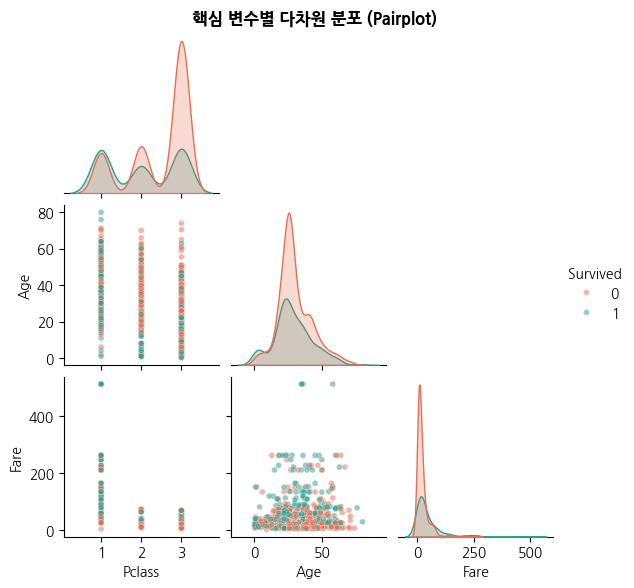

In [10]:
# 핵심 숫자형 변수의 다차원 분포 — 생존(청록) vs 사망(주황)
core = ["Survived", "Pclass", "Age", "Fare"]
g = sns.pairplot(tt[core], hue="Survived",
                 palette={0: C_DIED, 1: C_SURV},
                 height=1.9, corner=True,
                 plot_kws={"alpha": 0.5, "s": 18})
g.fig.suptitle("핵심 변수별 다차원 분포 (Pairplot)", y=1.02, fontweight="bold")
plt.show()

## 4.2. 단일 변수별 생존 분석

각 변수가 생존에 미치는 영향을 **두 가지 그래프**로 함께 확인합니다.

- **① 생존자 수 · 사망자 수** — 누적 막대로 그룹별 *절대 규모*를 보여줍니다.
- **② 생존률(%)** — 그룹별 *비율*을 보여주며, 회색 점선은 **전체 평균 생존률(37.7%)** 입니다.

### 4-2-1. 객실 등급 (Pclass)

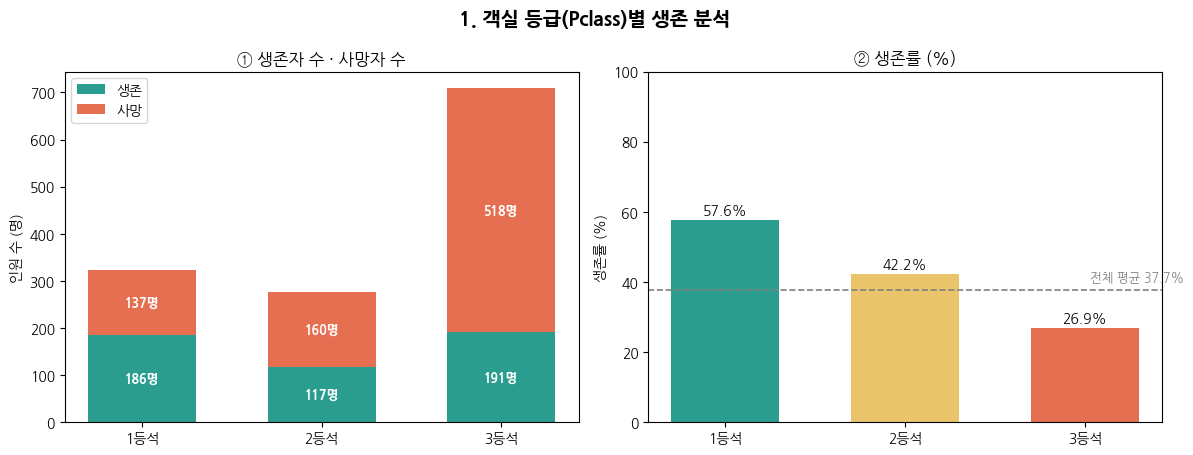

     인원수   생존   사망  생존률(%)
1등석  323  186  137    57.6
2등석  277  117  160    42.2
3등석  709  191  518    26.9


In [11]:
plot_survival_by(
    tt, "Pclass", "1. 객실 등급(Pclass)별 생존 분석",
    order=[1, 2, 3],
    label_map={1: "1등석", 2: "2등석", 3: "3등석"},
    rate_palette=C_CLASS)

### 4-2-2. 성별 (Sex) — 가장 강력한 단일 변수

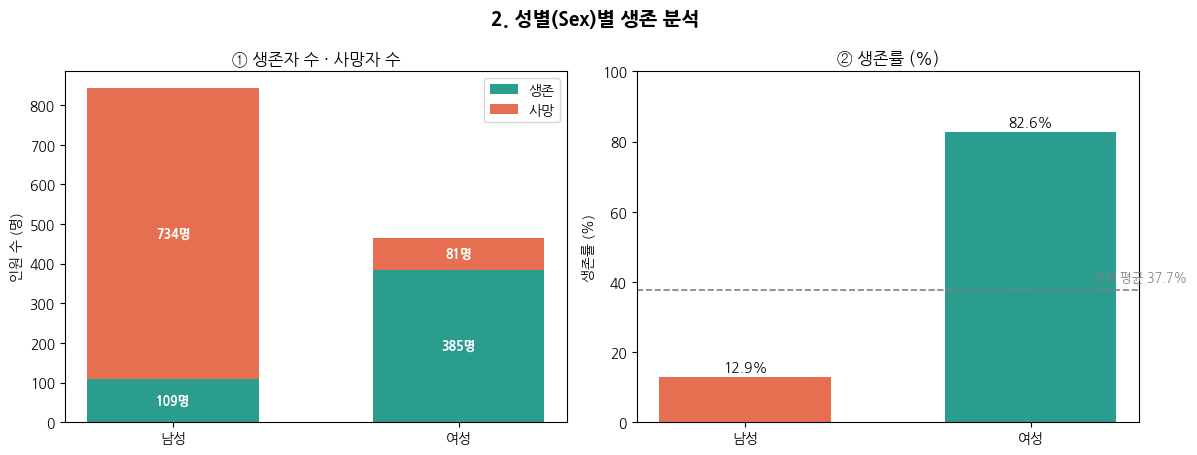

    인원수   생존   사망  생존률(%)
남성  843  109  734    12.9
여성  466  385   81    82.6


In [12]:
plot_survival_by(
    tt, "Sex", "2. 성별(Sex)별 생존 분석",
    order=["male", "female"],
    label_map={"male": "남성", "female": "여성"},
    rate_palette=[C_DIED, C_SURV])

### 4-2-3. 탑승 항구 (Embarked)

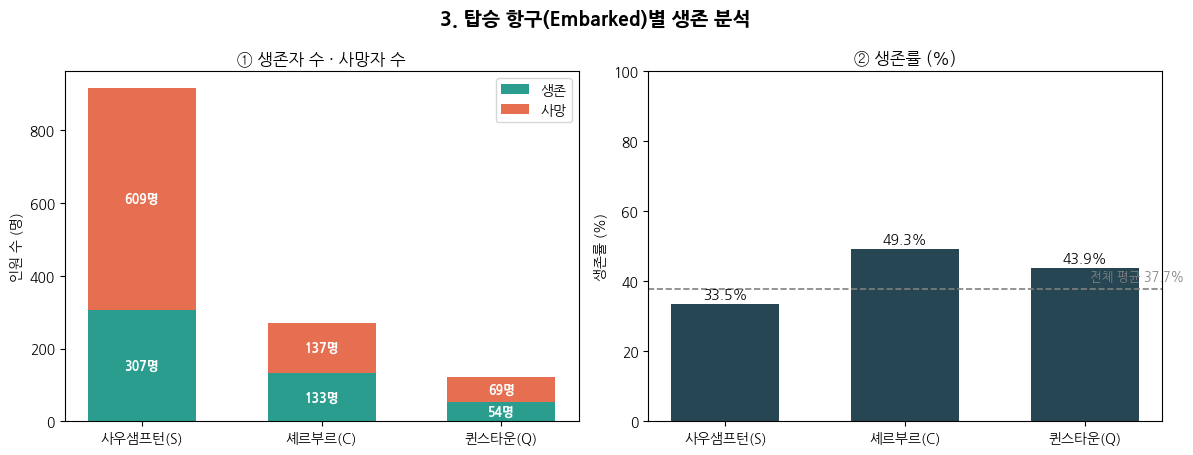

          인원수   생존   사망  생존률(%)
사우샘프턴(S)  916  307  609    33.5
셰르부르(C)   270  133  137    49.3
퀸스타운(Q)   123   54   69    43.9


In [13]:
plot_survival_by(
    tt, "Embarked", "3. 탑승 항구(Embarked)별 생존 분석",
    order=["S", "C", "Q"],
    label_map={"S": "사우샘프턴(S)", "C": "셰르부르(C)", "Q": "퀸스타운(Q)"})

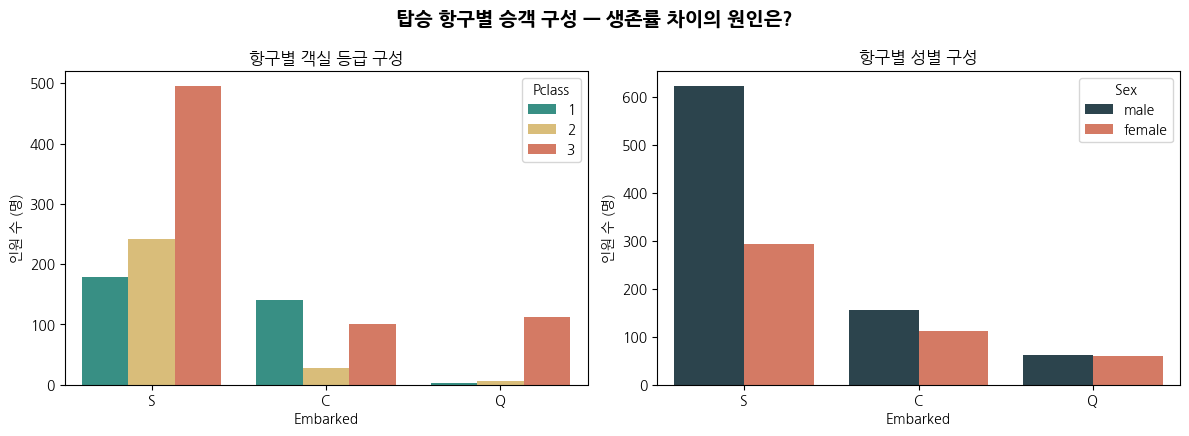

In [14]:
# 탑승 항구별 '객실 등급' 구성과 '성별' 구성 — 생존률 차이의 원인 추적
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
fig.suptitle("탑승 항구별 승객 구성 — 생존률 차이의 원인은?",
             fontweight="bold", fontsize=14)

sns.countplot(x="Embarked", hue="Pclass", data=tt, order=["S", "C", "Q"],
              palette=C_CLASS, ax=ax[0])
ax[0].set_title("항구별 객실 등급 구성")
ax[0].set_xlabel("Embarked"); ax[0].set_ylabel("인원 수 (명)")
ax[0].legend(title="Pclass")

sns.countplot(x="Embarked", hue="Sex", data=tt, order=["S", "C", "Q"],
              palette=[C_RATE, C_DIED], ax=ax[1])
ax[1].set_title("항구별 성별 구성")
ax[1].set_xlabel("Embarked"); ax[1].set_ylabel("인원 수 (명)")
ax[1].legend(title="Sex")

plt.tight_layout()
plt.show()

### 4-2-4. 형제·배우자 수 (SibSp)

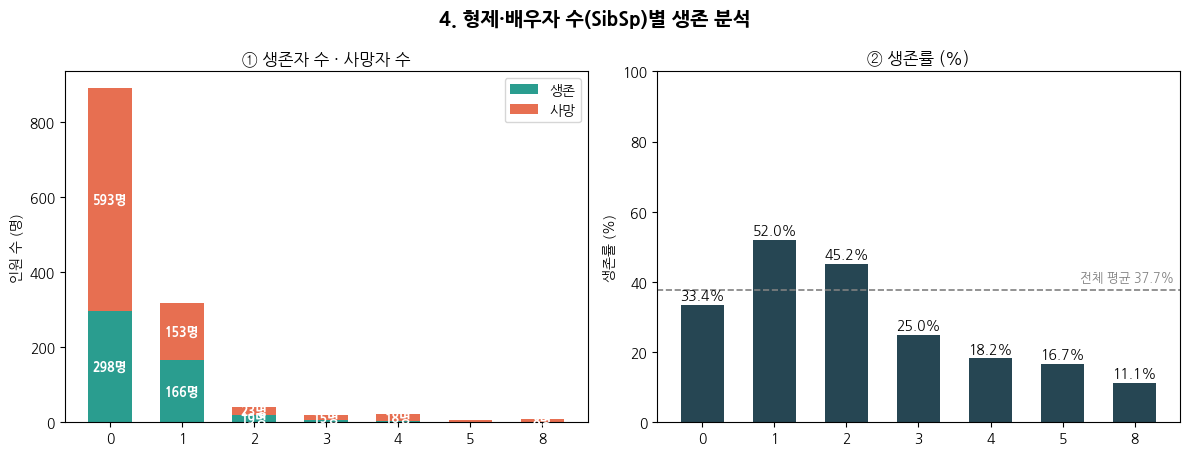

   인원수   생존   사망  생존률(%)
0  891  298  593    33.4
1  319  166  153    52.0
2   42   19   23    45.2
3   20    5   15    25.0
4   22    4   18    18.2
5    6    1    5    16.7
8    9    1    8    11.1


In [15]:
plot_survival_by(
    tt, "SibSp", "4. 형제·배우자 수(SibSp)별 생존 분석",
    order=sorted(tt["SibSp"].unique()))

### 4-2-5. 부모·자녀 수 (Parch)

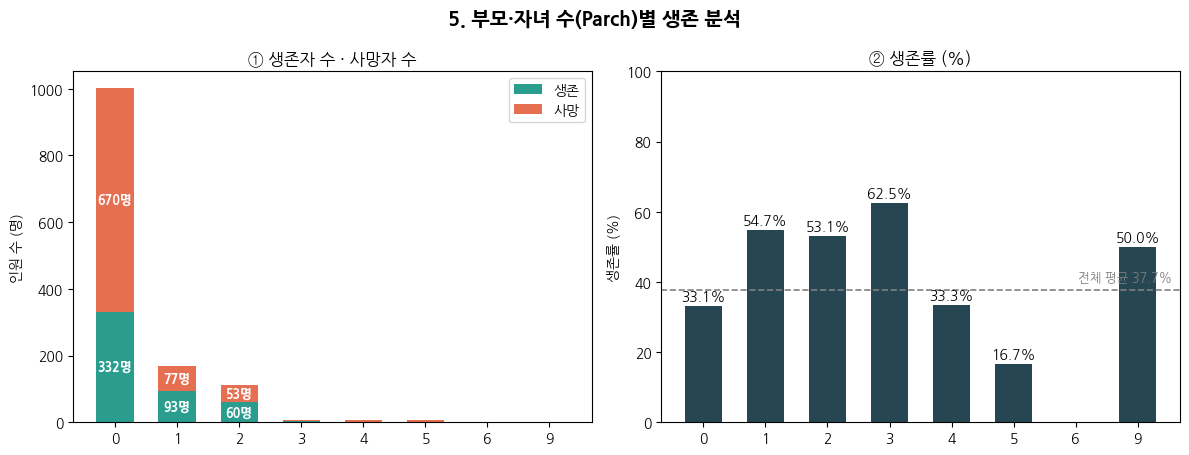

    인원수   생존   사망  생존률(%)
0  1002  332  670    33.1
1   170   93   77    54.7
2   113   60   53    53.1
3     8    5    3    62.5
4     6    2    4    33.3
5     6    1    5    16.7
6     2    0    2     0.0
9     2    1    1    50.0


In [16]:
plot_survival_by(
    tt, "Parch", "5. 부모·자녀 수(Parch)별 생존 분석",
    order=sorted(tt["Parch"].unique()))

### 4-2-6. 연령대 (Age Group)

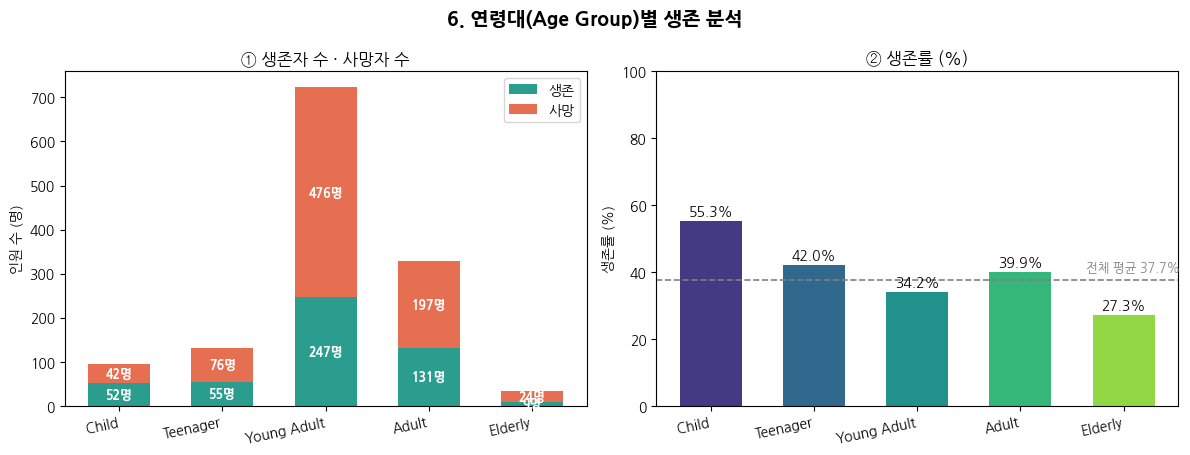

             인원수   생존   사망  생존률(%)
Child         94   52   42    55.3
Teenager     131   55   76    42.0
Young Adult  723  247  476    34.2
Adult        328  131  197    39.9
Elderly       33    9   24    27.3


In [17]:
age_order = ["Child", "Teenager", "Young Adult", "Adult", "Elderly"]
plot_survival_by(
    tt, "Age_Bin", "6. 연령대(Age Group)별 생존 분석",
    order=age_order, rotate=12,
    rate_palette=sns.color_palette("viridis", 5))

### 4-2-7. 요금 구간 (Fare Group)

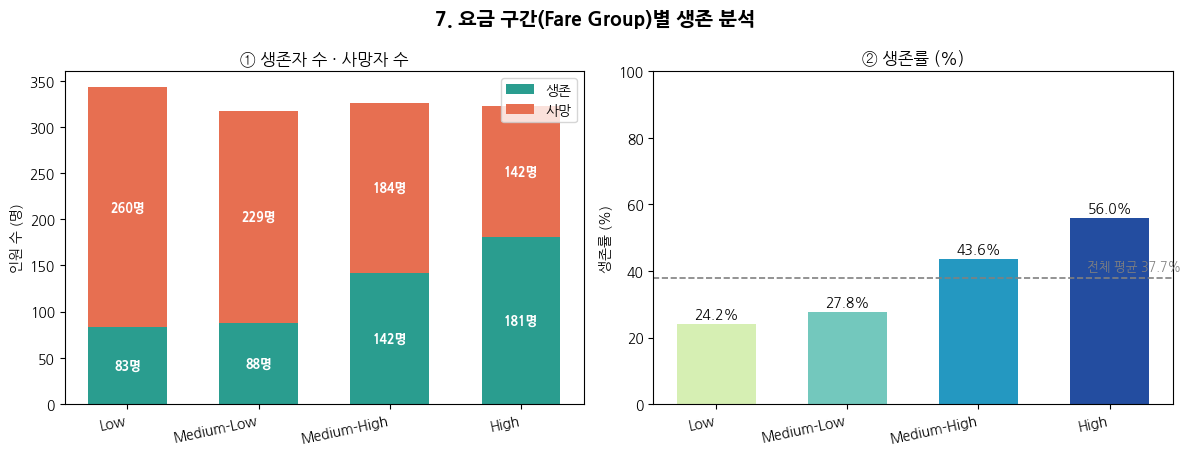

             인원수   생존   사망  생존률(%)
Low          343   83  260    24.2
Medium-Low   317   88  229    27.8
Medium-High  326  142  184    43.6
High         323  181  142    56.0


In [18]:
fare_order = ["Low", "Medium-Low", "Medium-High", "High"]
plot_survival_by(
    tt, "Fare_Bin", "7. 요금 구간(Fare Group)별 생존 분석",
    order=fare_order, rotate=12,
    rate_palette=sns.color_palette("YlGnBu", 4))

### 4-2-8. 객실 번호 기록 유무 (Cabin)

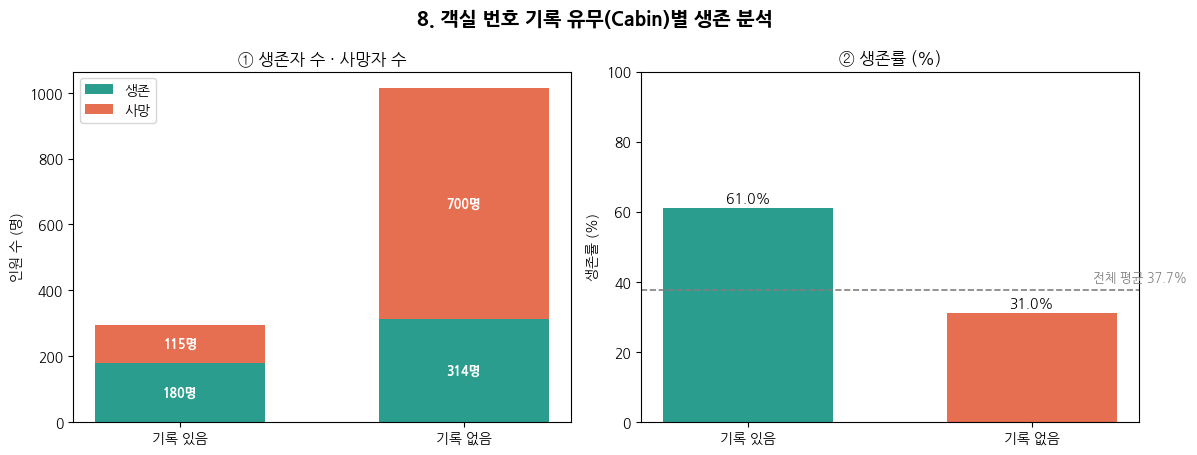

        인원수   생존   사망  생존률(%)
기록 있음   295  180  115    61.0
기록 없음  1014  314  700    31.0


In [19]:
plot_survival_by(
    tt, "Cabin_Bin", "8. 객실 번호 기록 유무(Cabin)별 생존 분석",
    order=["Yes", "No"],
    label_map={"Yes": "기록 있음", "No": "기록 없음"},
    rate_palette=[C_SURV, C_DIED])

## 4.3. 변수 간 상관관계 종합

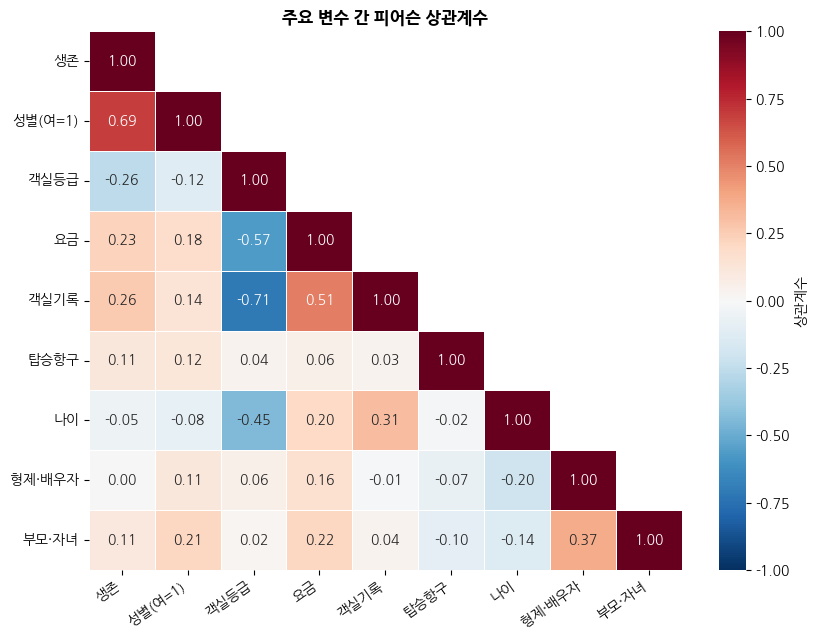

생존(Survived)과의 상관계수 — 절댓값이 큰 순:
성별(여=1)    0.69
객실등급      -0.26
객실기록       0.26
요금         0.23
탑승항구       0.11
부모·자녀      0.11
나이        -0.05
형제·배우자     0.00


In [20]:
# 문자형 변수를 숫자로 인코딩
tt["Sex_encoded"]      = tt["Sex"].map({"male": 0, "female": 1})
tt["Embarked_encoded"] = tt["Embarked"].map({"S": 0, "C": 1, "Q": 2})
tt["Cabin_encoded"]    = tt["Cabin_Bin"].map({"Yes": 1, "No": 0})

cols = {"Survived": "생존", "Sex_encoded": "성별(여=1)", "Pclass": "객실등급",
        "Fare": "요금", "Cabin_encoded": "객실기록", "Embarked_encoded": "탑승항구",
        "Age": "나이", "SibSp": "형제·배우자", "Parch": "부모·자녀"}
corr = tt[list(cols)].corr().rename(index=cols, columns=cols)

# 상단 삼각형을 가려 한눈에 보기 쉽게
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white", mask=mask,
            cbar_kws={"label": "상관계수"})
plt.title("주요 변수 간 피어슨 상관계수", fontweight="bold")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

order = corr["생존"].drop("생존").abs().sort_values(ascending=False).index
print("생존(Survived)과의 상관계수 — 절댓값이 큰 순:")
print(corr["생존"].drop("생존").reindex(order).round(2).to_string())

# 5. 분석 결과

항목별 분석을 종합하면, 타이타닉호의 생존을 가른 **세 가지 핵심 원리**가 드러납니다.

### ① 사회적 약자 우선 구조 원칙의 증명
### ② 객실 등급(자본)에 따른 생존률 격차
### ③ 동반 인원 수에 따른 비선형 효과

# 6. 인사이트 도출

## 3등급 탑승 고객이 살아남기 위한 전략

**전략 1: 혼자가 아닌 2~3인의 '적정 규모 동반자'를 구성하기**

단독 탑승(SibSp, Parch = 0)한 3등실 승객은 선내 지리에 어둡고 고립되어 사망률이 극대화되었다. 반면, 1~3명의 동반자가 있던 경우 생존율이 피크를 찍었다.

따라서 3등실 승객이 살기 위해서는 혼자 움직이는 각자도생을 버리고, 선내에서 마음이 맞는 동료나 가족 2~3인과 결성하여 정보를 공유하고 서로를 이끌어주는 상호 구조 메커니즘을 발동했어야 한다. (단, 4인 이상의 대가족은 이동 지연을 유발하므로 피해야 한다.)

**전략 2: Q(퀸즈타운) 지역 탑승객들의 대피 동선을 벤치마킹하기**

3등실 중에서도 S 지역 남성 중심의 서민층은 생존율이 바닥이었던 반면, 여성 비율이 높았던 Q 지역의 3등실은 대피 과정에서 '여성 우선 구조 원칙'의 흐름을 탈 기회가 더 많았다.

즉, 3등실 안에서도 무작정 남성 노동자 무리에 휩쓸려 다니기보다, 여성과 아이들이 먼저 모여 대피하는 동선(Q 지역 승객들의 이동 경로)에 밀착하여 구명보트가 있는 갑판으로의 접근권을 함께 확보하는 것이 생존 확률을 조금이라도 높이는 길이었다.

## 남성 승객이 살아남기 위한 전략

**전략 1: '가족 중심의 보호자' 포지션을 취하기**

타이타닉 데이터에서 아이(Child)나 부인(Parch, SibSp)을 동반한 가장 혹은 보호자 역할을 한 남성들은 구명보트 탑승 과정에서 가족을 보살핀다는 명분 하에 함께 탑승하거나, 여성 우선 구조의 낙수효과를 얻을 확률이 데이터상으로 더 존재했다.

따라서 각자도생하는 것보다, 사회적 약자(가족)를 부양하는 보호자로서 움직였어야 한다.

**전략 2: C(셰르부르) 지역의 '자본 권력' 흐름에 편승**

페어플롯과 추세선에서 보았듯, 남성 중 유일하게 생존의 불씨가 살아있던 집단은 1등실 초고가 티켓(Fare 200달러 이상)을 소지한 부유층 남성들이었다. 이들은 성별의 불리함을 '자본의 힘(갑판 우선 진입권 및 선사 혜택)'으로 생존율을 높였다.

만약 자본이 부족한 남성이라면, 대피 상황에서 1등실 부유층 승객들이 대거 탑승했던 C 지역 승객들의 동선을 파악하고, 그들이 자본의 힘으로 열어젖힌 '특별 대피 통로'를 물리적으로 추격해 탈출했어야 했다.

# 7. 느낀점

분석을 진행하며 데이터 표면에 드러난 단순 수치나 단편적인 지표를 온전히 신뢰할 수 없고 입체적인 흐름을 파악하는 것이 중요하다고 느꼈다.

가장 대표적으로 동반 가족 수(SibSp, Parch) 변수의 경우, 선형 상관계수는 0에 가깝게 측정되어 얼핏 생존율과 무관한 것처럼 보였다. 그러나 시각화를 수행해 본 결과, 혼자일 때보다 1~3명의 적정 가족을 동반했을 때 생존율이 정점을 찍고 대가족일 때 다시 추락하는 명확한 '비선형적 흐름'을 확인할 수 있었다.

더불어, Fare 변수의 박스플롯에서 발견한 많은 이상치가 데이터의 오류가 아닌 타이타닉호 내부의 빈부격차를 대변한다는 점과, 최고 생존율을 보인 C 지역이나은 예상한대로 1등급 고객이 많았지만, Q등급은 1등급 고객이 적었지만 여성이 많았기 때문에 생존율이 높았다.

왜곡 없는 인사이트를 도출하기 위해서는, 통계적 지표 산출에만 의존하지 않고 시각화와 변수 간 교차 검증 등 다방면의 데이터 분석을 수행해야 함을 배웠다. 이번 프로젝트는 데이터 분석을 하며 마주할 수많은 데이터셋을 어떤 태도로 바라보아야 하는지 이정표를 세워준 소중한 경험이었다
